<a href="https://colab.research.google.com/github/PrantoMondol11/Machine-learning-/blob/main/AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [2]:
df=pd.DataFrame()
df["cl1"]=[2,3,1,3,2,1,3,5,6,7]
df["cl2"]=[3,2,4,5,3,8,4,7,3,2]
df["taget"]=[1,1,1,0,1,0,0,0,1,1]

In [3]:
df

,cl1,cl2,taget
0,2,3,1
1,3,2,1
2,1,4,1
3,3,5,0
4,2,3,1
5,1,8,0
6,3,4,0
7,5,7,0
8,6,3,1
9,7,2,1


In [4]:
df["weight"]=1/df.shape[0]

In [5]:
df

,cl1,cl2,taget,weight
0,2,3,1,0.1
1,3,2,1,0.1
2,1,4,1,0.1
3,3,5,0,0.1
4,2,3,1,0.1
5,1,8,0,0.1
6,3,4,0,0.1
7,5,7,0,0.1
8,6,3,1,0.1
9,7,2,1,0.1


<Axes: xlabel='cl1', ylabel='cl2'>

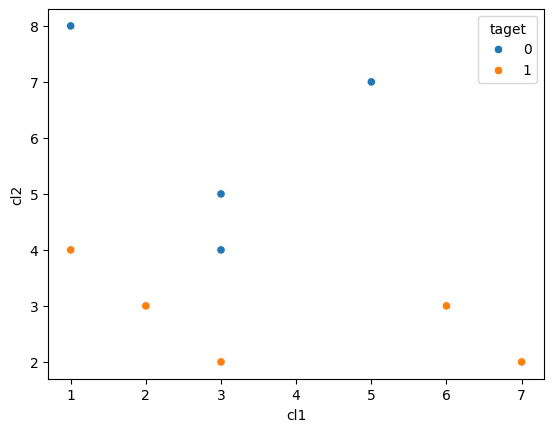

In [6]:
import seaborn as sns
sns.scatterplot(x=df["cl1"],y=df["cl2"],hue=df["taget"])

In [7]:
from sklearn.tree import DecisionTreeClassifier


In [18]:
X_train=df.iloc[:,0:2].values
y_train=df.iloc[:,2].values

In [19]:
X_train

array([[2, 3],
       [3, 2],
       [1, 4],
       [3, 5],
       [2, 3],
       [1, 8],
       [3, 4],
       [5, 7],
       [6, 3],
       [7, 2]])

In [20]:
clf=DecisionTreeClassifier(max_depth=1)


In [21]:
model=clf.fit(X_train,y_train)

In [22]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[1] <= 3.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.625, 0.5, '  False')]

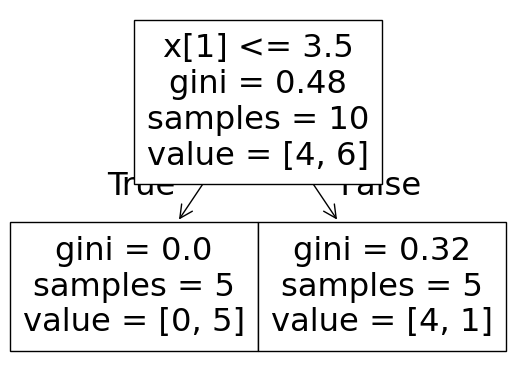

In [23]:
plot_tree(model)

<Axes: >

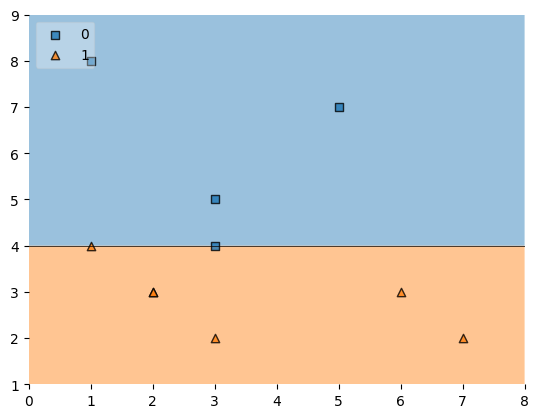

In [24]:
plot_decision_regions(X_train,y_train,model,legend=2)

In [25]:
df["predict"]=clf.predict(X_train)

In [26]:
df

,cl1,cl2,taget,weight,predict
0,2,3,1,0.1,1
1,3,2,1,0.1,1
2,1,4,1,0.1,0
3,3,5,0,0.1,0
4,2,3,1,0.1,1
5,1,8,0,0.1,0
6,3,4,0,0.1,0
7,5,7,0,0.1,0
8,6,3,1,0.1,1
9,7,2,1,0.1,1


In [27]:
def calculate_model_weight(error):
  return .5*(np.log2((1-error)/error))

In [29]:
alpha1=calculate_model_weight(.1)

In [34]:
alpha1

np.float64(1.584962500721156)

In [44]:
def update_row_weight(df,alpha=alpha1):
   if df["taget"] == df["predict"]:
      return df["weight"]*(np.exp(-alpha))
   else:
      return df["weight"]*(np.exp(alpha))


In [45]:
df["updated_weight"]=df.apply(update_row_weight,axis=1)

In [46]:
df

,cl1,cl2,taget,weight,predict,updated_weight
0,2,3,1,0.1,1,0.020496
1,3,2,1,0.1,1,0.020496
2,1,4,1,0.1,0,0.487911
3,3,5,0,0.1,0,0.020496
4,2,3,1,0.1,1,0.020496
5,1,8,0,0.1,0,0.020496
6,3,4,0,0.1,0,0.020496
7,5,7,0,0.1,0,0.020496
8,6,3,1,0.1,1,0.020496
9,7,2,1,0.1,1,0.020496


In [47]:
df["updated_weight"].sum()

np.float64(0.6723707719933405)

In [48]:
df["normalized_weight"]=df["updated_weight"]/df["updated_weight"].sum()

In [49]:
df

,cl1,cl2,taget,weight,predict,updated_weight,normalized_weight
0,2,3,1,0.1,1,0.020496,0.030483
1,3,2,1,0.1,1,0.020496,0.030483
2,1,4,1,0.1,0,0.487911,0.725657
3,3,5,0,0.1,0,0.020496,0.030483
4,2,3,1,0.1,1,0.020496,0.030483
5,1,8,0,0.1,0,0.020496,0.030483
6,3,4,0,0.1,0,0.020496,0.030483
7,5,7,0,0.1,0,0.020496,0.030483
8,6,3,1,0.1,1,0.020496,0.030483
9,7,2,1,0.1,1,0.020496,0.030483


In [50]:
df["normalized_weight"].sum()

np.float64(0.9999999999999999)

In [53]:
df["cumsum_upper"]=np.cumsum(df["normalized_weight"])
df["cumsum_lower"]=df["cumsum_upper"]-df["normalized_weight"]

In [54]:
df

,cl1,cl2,taget,weight,predict,updated_weight,normalized_weight,cumsum_upper,cumsum_lower
0,2,3,1,0.1,1,0.020496,0.030483,0.030483,0.000000
1,3,2,1,0.1,1,0.020496,0.030483,0.060965,0.030483
2,1,4,1,0.1,0,0.487911,0.725657,0.786622,0.060965
3,3,5,0,0.1,0,0.020496,0.030483,0.817105,0.786622
4,2,3,1,0.1,1,0.020496,0.030483,0.847587,0.817105
5,1,8,0,0.1,0,0.020496,0.030483,0.878070,0.847587
6,3,4,0,0.1,0,0.020496,0.030483,0.908552,0.878070
7,5,7,0,0.1,0,0.020496,0.030483,0.939035,0.908552
8,6,3,1,0.1,1,0.020496,0.030483,0.969517,0.939035
9,7,2,1,0.1,1,0.020496,0.030483,1.000000,0.969517


In [55]:
def create_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
      a=np.random.random()
      for index,row in df.iterrows():
        if row["cumsum_upper"]>a and row["cumsum_lower"]< a:
          indices.append(index)
    return indices


In [56]:
indexs=create_new_dataset(df)
indexs

[2, 2, 2, 2, 2, 3, 2, 2, 2, 2]

In [57]:
df1=df.iloc[indexs,[0,1,2,3]]

In [58]:
df1

,cl1,cl2,taget,weight
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
3,3,5,0,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1


In [59]:
clf2=DecisionTreeClassifier()

In [71]:
X_train1=df1.iloc[:,0:2].values
Y_train1=df1.iloc[:,2].values
X_train1

array([[1, 4],
       [1, 4],
       [1, 4],
       [1, 4],
       [1, 4],
       [3, 5],
       [1, 4],
       [1, 4],
       [1, 4],
       [1, 4]])

In [68]:
clf2.fit(X_train1,Y_train1)

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[0] <= 2.0\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.625, 0.5, '  False')]

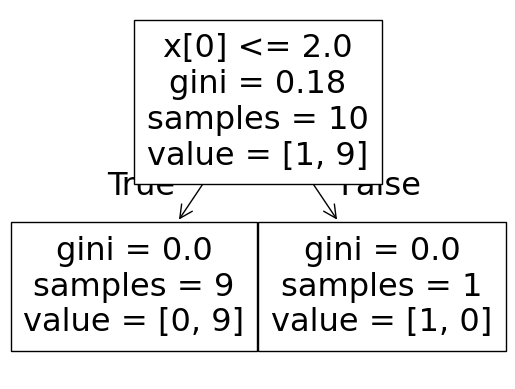

In [69]:
plot_tree(clf2)

<Axes: >

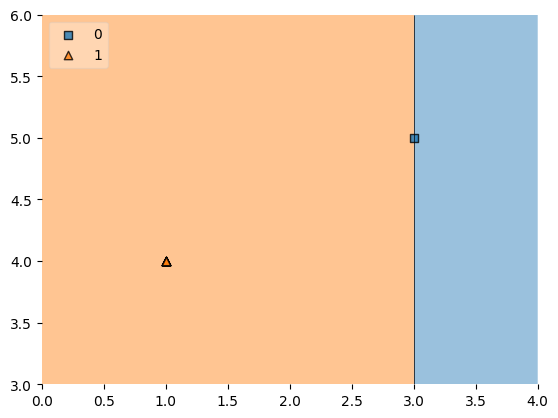

In [70]:
plot_decision_regions(X_train1,Y_train1,clf2,legend=2)

In [72]:
df1["predict"]=clf2.predict(X_train1)

In [73]:
df1

,cl1,cl2,taget,weight,predict
2,1,4,1,0.1,1
2,1,4,1,0.1,1
2,1,4,1,0.1,1
2,1,4,1,0.1,1
2,1,4,1,0.1,1
3,3,5,0,0.1,0
2,1,4,1,0.1,1
2,1,4,1,0.1,1
2,1,4,1,0.1,1
2,1,4,1,0.1,1


In [75]:
alpha2=calculate_model_weight(.001)

In [76]:
alpha2

np.float64(4.982170433896209)

In [79]:
def update_row_weight(df,alpha=alpha2):
   if df["taget"] == df["predict"]:
      return df["weight"]*(np.exp(-alpha))
   else:
      return df["weight"]*(np.exp(alpha))

In [80]:
df1["updated_weight"]=df1.apply(update_row_weight,axis=1)

In [81]:
df1

,cl1,cl2,taget,weight,predict,updated_weight
2,1,4,1,0.1,1,0.000686
2,1,4,1,0.1,1,0.000686
2,1,4,1,0.1,1,0.000686
2,1,4,1,0.1,1,0.000686
2,1,4,1,0.1,1,0.000686
3,3,5,0,0.1,0,0.000686
2,1,4,1,0.1,1,0.000686
2,1,4,1,0.1,1,0.000686
2,1,4,1,0.1,1,0.000686
2,1,4,1,0.1,1,0.000686


In [83]:
df1['normalized_weight']=1/df["updated_weight"].sum()
df1["cumsum_upper"]=np.cumsum(df1['normalized_weight'])
df1["cumsum_lower"]=df1["cumsum_upper"]-df1["normalized_weight"]

In [84]:
inices2=create_new_dataset(df1)

In [85]:
inices2

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [86]:
df2=df1.iloc[inices2,0:4]

In [87]:
df2

,cl1,cl2,taget,weight
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1
2,1,4,1,0.1


In [94]:
query=np.array([3,5]).reshape(1,2)

In [95]:
query

array([[3, 5]])

In [96]:
clf.predict(query)

array([0])

In [97]:
clf2.predict(query)

array([0])

In [98]:
p=alpha1*0+alpha2*0

In [99]:
np.sign(p)

np.float64(0.0)